# CPSTN(Training) - Draft 5

**Purpose:** robust, reproducible, multi-dataset CPSTN traffic forecasting training pipeline.

### Draft 5 goals
- Preserve the existing CPSTN spatio-temporal architecture.
- Use the single observed traffic-speed feature actually present in the supplied datasets; do not invent a 3-feature input tensor.
- Train the same learnable CPSTN parameters sequentially across compatible traffic datasets.
- Keep graph structure, sensor IDs, and normalization dataset-specific.
- Allow substantially longer training with early stopping and best-model checkpointing.
- Use GPU-friendly AMP, pinned/persistent DataLoaders, non-blocking transfers, gradient clipping, and efficient tensor operations.
- Validate datasets and graphs before training.
- Produce a checkpoint with both legacy single-dataset fields and explicit multi-dataset metadata for CPSTN Testing Draft 5 compatibility.
- Never fabricate missing data, metrics, or accuracy improvements.

**Important:** A* is not part of training. It belongs only in the testing/inference stage after CPSTN generates predictions.

In [1]:
# 1. Install only packages not guaranteed by the runtime.
!pip -q install gdown tables scipy scikit-learn tqdm

In [2]:
# 2. Imports, reproducibility, device and runtime capabilities
import os, time, math, random, pickle, json, urllib.request, warnings, gc
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

SEED = 42

def set_seed(seed=SEED, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.use_deterministic_algorithms(True, warn_only=True)
        torch.backends.cudnn.benchmark = False
    else:
        # Faster convolution autotuning; exact bitwise reproducibility is not guaranteed.
        torch.backends.cudnn.benchmark = True

set_seed(SEED, deterministic=False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CUDA_AVAILABLE = torch.cuda.is_available()
if CUDA_AVAILABLE:
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("CUDA available:", CUDA_AVAILABLE)
if CUDA_AVAILABLE:
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
print("Random seed:", SEED)
print("Deterministic algorithms:", False, "(speed/reproducibility trade-off)")

PyTorch: 2.11.0+cu128
Device: cuda
CUDA available: True
GPU: Tesla T4
VRAM GB: 14.56
Random seed: 42
Deterministic algorithms: False (speed/reproducibility trade-off)


## 3. Central configuration

Critical hyperparameters live here rather than being scattered through the notebook.

The default is configured for a real run. Set `FAST_DEBUG = True` for a short end-to-end smoke test before a full run.

In [3]:
# 3. Central configuration
DATASETS = ["METR-LA", "PEMS-BAY"]

FAST_DEBUG = False
SKIP_INVALID_DATASETS = False
ALLOW_CPU_FALLBACK = True
AUTO_REDUCE_BATCH_ON_OOM = True  # one controlled batch-size reduction; never retries indefinitely

INPUT_LENGTH = 12
FORECAST_HORIZON = 12

MAX_EPOCHS = 200 if not FAST_DEBUG else 2
BATCH_SIZE = 64
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 12 if not FAST_DEBUG else 1
LR_PATIENCE = 3
LR_FACTOR = 0.5
MIN_LR = 1e-5
GRAD_CLIP = 2.0

HIDDEN_DIM = 32
DROPOUT = 0.10
NUMBER_OF_BLOCKS = 3
DILATIONS = [1, 2, 4]

NUM_WORKERS = 2
PIN_MEMORY = CUDA_AVAILABLE
PERSISTENT_WORKERS = NUM_WORKERS > 0
USE_AMP = CUDA_AVAILABLE
AMP_DTYPE = torch.float16

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.10

# Each epoch performs one complete pass over every successfully loaded dataset.
# Dataset validation losses are combined by validation-sample count.
DATASET_ORDER = list(DATASETS)

ROOT = Path("/content/cpstn_draft5")
ROOT.mkdir(parents=True, exist_ok=True)
DATA_DIR = ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = ROOT / "CPSTN(Training)-Draft5_best.pt"
SUMMARY_PATH = ROOT / "CPSTN(Training)-Draft5_summary.json"
FINAL_CHECKPOINT_PATH = ROOT / "CPSTN(Training)-Draft5_final.pt"
RESULTS_DIR = ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"
for _p in (RESULTS_DIR, PLOTS_DIR, PREDICTIONS_DIR):
    _p.mkdir(parents=True, exist_ok=True)

print("Configured datasets:", DATASETS)
print("Max epochs:", MAX_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("AMP:", USE_AMP, AMP_DTYPE if USE_AMP else "disabled")

Configured datasets: ['METR-LA', 'PEMS-BAY']
Max epochs: 200
Batch size: 64
AMP: True torch.float16


In [4]:
# Colab/T4 runtime sanity check
print("=" * 70)
print("COLAB RUNTIME CHECK")
print("=" * 70)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type != "cuda":
    raise RuntimeError("GPU is not enabled. In Colab select Runtime -> Change runtime type -> T4 GPU.")
gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
print("GPU:", gpu_name)
print("VRAM:", f"{vram_gb:.2f} GB")
print("CUDA:", torch.version.cuda)
print("AMP:", USE_AMP, AMP_DTYPE)
if "T4" not in gpu_name:
    print("WARNING: This notebook is GPU-compatible, but the active GPU is not a T4.")
print("STATUS: GPU runtime ready")


COLAB RUNTIME CHECK
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4
VRAM: 14.56 GB
CUDA: 12.8
AMP: True torch.float16
STATUS: GPU runtime ready


In [5]:
# 4. Dataset configuration
DATA_CFG = {
    "METR-LA": {
        "h5": DATA_DIR / "metr-la.h5",
        "h5_url": "https://drive.google.com/uc?export=download&id=1pAGRfzMx6K9WWsfDcD1NMbIif0T0saFC",
        "adj": DATA_DIR / "adj_mx.pkl",
        "adj_url": "https://raw.githubusercontent.com/liyaguang/DCRNN/master/data/sensor_graph/adj_mx.pkl",
        "locations": DATA_DIR / "graph_sensor_locations.csv",
        "locations_url": "https://raw.githubusercontent.com/liyaguang/DCRNN/master/data/sensor_graph/graph_sensor_locations.csv",
        "expected_nodes": 207,
    },
    "PEMS-BAY": {
        "h5": DATA_DIR / "pems-bay.h5",
        "h5_url": "https://drive.google.com/uc?export=download&id=1wD-mHlqAb2mtHOe_68fZvDh1LpDegMMq",
        "adj": DATA_DIR / "adj_mx_bay.pkl",
        "adj_url": "https://raw.githubusercontent.com/liyaguang/DCRNN/master/data/sensor_graph/adj_mx_bay.pkl",
        "locations": DATA_DIR / "graph_sensor_locations_bay.csv",
        "locations_url": "https://raw.githubusercontent.com/liyaguang/DCRNN/master/data/sensor_graph/graph_sensor_locations_bay.csv",
        "expected_nodes": 325,
    },
}

unknown = [d for d in DATASETS if d not in DATA_CFG]
if unknown:
    raise ValueError(f"Unsupported dataset(s): {unknown}. Supported: {sorted(DATA_CFG)}")

print("Dataset configuration validated.")

Dataset configuration validated.


## 4. Dataset loading and validation

Each dataset remains an independent traffic tensor with its own:
- sensor IDs,
- graph/adjacency matrix,
- train-only normalization statistics,
- chronological train/validation/test windows.

METR-LA and PEMS-BAY are **not concatenated along the sensor dimension**.

In [6]:
# 5. Download benchmark data and graph metadata
import gdown

def download_file(url, path, drive_id=None):
    path = Path(path)
    if path.exists() and path.stat().st_size > 0:
        print("Using cached:", path.name, f"({path.stat().st_size/1024**2:.1f} MB)")
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    if drive_id:
        print("Downloading from Google Drive:", path.name)
        result = gdown.download(id=drive_id, output=str(path), quiet=False)
        if result is None:
            raise RuntimeError(f"Google Drive download failed: {path}")
    else:
        print("Downloading:", path.name)
        urllib.request.urlretrieve(url, path)
    if not path.exists() or path.stat().st_size == 0:
        raise RuntimeError(f"Download failed: {path}")

def ensure_dataset_files(name):
    cfg = DATA_CFG[name]
    drive_id = cfg["h5_url"].split("id=")[-1]
    download_file(cfg["h5_url"], cfg["h5"], drive_id=drive_id)
    download_file(cfg["adj_url"], cfg["adj"])
    if cfg["locations"] is not None:
        try:
            download_file(cfg["locations_url"], cfg["locations"])
        except Exception as e:
            warnings.warn(f"{name}: location metadata unavailable: {e}")
            cfg["locations"] = None
    return cfg

dataset_file_status = {}
for name in DATASETS:
    try:
        cfg = ensure_dataset_files(name)
        dataset_file_status[name] = "available"
    except Exception as e:
        dataset_file_status[name] = f"FAILED: {e}"
        if not SKIP_INVALID_DATASETS:
            raise RuntimeError(
                f"DATASET FAILURE: {name}\n"
                f"Path: {DATA_CFG[name]['h5']}\n"
                f"Failure: {e}"
            ) from e

print("File status:")
for k, v in dataset_file_status.items():
    print(f" - {k}: {v}")

Downloading...
From: https://drive.google.com/uc?id=1pAGRfzMx6K9WWsfDcD1NMbIif0T0saFC
To: /content/cpstn_draft5/data/metr-la.h5
100%|██████████| 57.0M/57.0M [00:01<00:00, 39.9MB/s]


Downloading: adj_mx.pkl
Downloading: graph_sensor_locations.csv


Downloading...
From (original): https://drive.google.com/uc?id=1wD-mHlqAb2mtHOe_68fZvDh1LpDegMMq
From (redirected): https://drive.google.com/uc?id=1wD-mHlqAb2mtHOe_68fZvDh1LpDegMMq&confirm=t&uuid=590829e5-2aa2-401c-be00-0ff1f8d2b8eb
To: /content/cpstn_draft5/data/pems-bay.h5
100%|██████████| 136M/136M [00:02<00:00, 50.2MB/s]


Downloading: adj_mx_bay.pkl
Downloading: graph_sensor_locations_bay.csv
File status:
 - METR-LA: available
 - PEMS-BAY: available


In [7]:
# 6. Dataset loader + strict data/graph validation
def load_and_validate_dataset(name):
    cfg = DATA_CFG[name]

    try:
        try:
            df = pd.read_hdf(cfg["h5"], key="speed")
        except (KeyError, ValueError):
            df = pd.read_hdf(cfg["h5"])
    except Exception as e:
        raise RuntimeError(f"{name}: failed to read HDF5 traffic data at {cfg['h5']}: {e}") from e

    if df.empty:
        raise ValueError(f"{name}: traffic dataset is empty.")

    df.index = pd.to_datetime(df.index, errors="coerce")
    if df.index.isna().any():
        raise ValueError(f"{name}: invalid timestamp(s) found.")
    if not df.index.is_monotonic_increasing:
        raise ValueError(f"{name}: timestamps are not ordered.")
    if df.index.has_duplicates:
        raise ValueError(f"{name}: duplicate timestamps found.")

    df.columns = [str(c) for c in df.columns]
    if len(set(df.columns)) != len(df.columns):
        raise ValueError(f"{name}: duplicate sensor IDs found in traffic data.")

    if df.shape[1] != cfg["expected_nodes"]:
        raise ValueError(
            f"{name}: expected {cfg['expected_nodes']} sensors, got {df.shape[1]}."
        )

    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan)
    missing_before = int(df.isna().sum().sum())

    # Benchmark zero-speed values are treated as missing, matching Draft 4 behavior.
    df = df.replace(0.0, np.nan)
    df = df.interpolate(method="linear", limit_direction="both").ffill().bfill()

    if not np.isfinite(df.to_numpy(dtype=np.float32)).all():
        raise ValueError(f"{name}: NaN/Inf remains after preprocessing.")

    speed = df.to_numpy(dtype=np.float32)
    sensor_ids = list(df.columns)
    timestamps = df.index

    # Graph
    try:
        with open(cfg["adj"], "rb") as f:
            obj = pickle.load(f, encoding="latin1")
    except Exception as e:
        raise RuntimeError(f"{name}: failed to read adjacency file {cfg['adj']}: {e}") from e

    if isinstance(obj, (tuple, list)) and len(obj) >= 3:
        graph_sensor_ids = [str(x) for x in obj[0]]
        raw_adj = np.asarray(obj[-1], dtype=np.float32)
    else:
        graph_sensor_ids = None
        raw_adj = np.asarray(obj, dtype=np.float32)

    expected_shape = (cfg["expected_nodes"], cfg["expected_nodes"])
    if raw_adj.shape != expected_shape:
        raise ValueError(
            f"{name}: graph dimension mismatch. Expected {expected_shape}, got {raw_adj.shape}."
        )

    if graph_sensor_ids is not None:
        if len(graph_sensor_ids) != cfg["expected_nodes"]:
            raise ValueError(f"{name}: graph sensor metadata length is invalid.")
        if set(graph_sensor_ids) != set(sensor_ids):
            missing = sorted(set(sensor_ids) - set(graph_sensor_ids))[:10]
            extra = sorted(set(graph_sensor_ids) - set(sensor_ids))[:10]
            raise ValueError(
                f"{name}: sensor-ID mismatch. Missing in graph: {missing}; extra: {extra}"
            )
        graph_pos = {sid: i for i, sid in enumerate(graph_sensor_ids)}
        order = [graph_pos[sid] for sid in sensor_ids]
        A = raw_adj[np.ix_(order, order)]
    else:
        # Only safe when the source graph exposes no IDs.
        A = raw_adj.copy()

    A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)
    if np.any(A < 0):
        A[A < 0] = 0
    np.fill_diagonal(A, 1.0)
    A = np.maximum(A, A.T)

    if not np.isfinite(A).all():
        raise ValueError(f"{name}: adjacency contains NaN/Inf after sanitization.")

    degree = A.sum(axis=1)
    if np.any(degree <= 0):
        raise ValueError(f"{name}: graph contains a zero-degree node.")

    D_inv_sqrt = 1.0 / np.sqrt(np.maximum(degree, 1e-8))
    A_norm = (D_inv_sqrt[:, None] * A * D_inv_sqrt[None, :]).astype(np.float32)

    if A_norm.shape != (speed.shape[1], speed.shape[1]):
        raise ValueError(
            f"{name}: graph/data mismatch. Graph={A_norm.shape}, traffic sensors={speed.shape[1]}"
        )
    if not np.isfinite(A_norm).all():
        raise ValueError(f"{name}: normalized adjacency contains NaN/Inf.")
    if not np.allclose(A_norm, A_norm.T, atol=1e-6):
        raise ValueError(f"{name}: normalized adjacency is not symmetric.")

    T, N = speed.shape
    train_end = int(T * TRAIN_FRACTION)
    val_end = int(T * (TRAIN_FRACTION + VAL_FRACTION))
    if train_end <= INPUT_LENGTH or val_end <= train_end or val_end >= T:
        raise ValueError(f"{name}: invalid train/validation/test split sizes.")

    train_mean = speed[:train_end].mean(axis=0).astype(np.float32)
    train_std = np.maximum(speed[:train_end].std(axis=0), 1e-3).astype(np.float32)
    speed_z = ((speed - train_mean) / train_std).astype(np.float32)

    if not np.isfinite(speed_z).all():
        raise ValueError(f"{name}: normalized traffic contains NaN/Inf.")

    return {
        "name": name,
        "speed": speed,
        "speed_z": speed_z,
        "timestamps": timestamps,
        "sensor_ids": sensor_ids,
        "A": A.astype(np.float32),
        "A_norm": A_norm,
        "train_mean": train_mean,
        "train_std": train_std,
        "train_end": train_end,
        "val_end": val_end,
        "T": T,
        "N": N,
        "missing_before": missing_before,
        "normalization": "per-sensor z-score; mean/std fitted on chronological training period only",
        "graph_dimensions": tuple(A.shape),
    }

prepared = {}
used_datasets = []
skipped_datasets = {}

for name in DATASETS:
    try:
        prepared[name] = load_and_validate_dataset(name)
        used_datasets.append(name)
    except Exception as e:
        skipped_datasets[name] = str(e)
        if not SKIP_INVALID_DATASETS:
            raise
        print(f"SKIPPED DATASET: {name} -> {e}")

if not used_datasets:
    raise RuntimeError("No valid datasets remain after validation.")

print("\nDATASET VALIDATION SUMMARY")
for name in used_datasets:
    d = prepared[name]
    print(
        f"{name}: sensors={d['N']}, samples={d['T']}, "
        f"train_end={d['train_end']}, val_end={d['val_end']}, "
        f"graph={d['graph_dimensions']}, missing_repaired={d['missing_before']}"
    )


DATASET VALIDATION SUMMARY
METR-LA: sensors=207, samples=34272, train_end=23990, val_end=27417, graph=(207, 207), missing_repaired=0
PEMS-BAY: sensors=325, samples=52116, train_end=36481, val_end=41692, graph=(325, 325), missing_repaired=0


## 5. Multi-dataset preparation

Windows are built independently for each dataset. This keeps different sensor counts and graph structures isolated while allowing the same CPSTN learnable parameters to be shared.

Only one dataset's materialized windows are held by the active training loop at a time, reducing unnecessary memory pressure.

In [8]:
# 7. Window construction and reusable DataLoaders
DEBUG_WINDOW_LIMIT = 256


def build_windows(
    speed_z,
    start,
    end,
    input_steps,
    horizon,
    max_windows=None,
):
    """Build chronological X/Y windows without leaking future targets."""
    speed_z = np.asarray(speed_z, dtype=np.float32)

    if speed_z.ndim != 2:
        raise ValueError(f"Expected [time, sensors], got {speed_z.shape}")

    n_time, n_sensors = speed_z.shape
    start = max(int(start), 0)
    end = min(int(end), n_time)

    first_t = max(start + input_steps, input_steps)
    last_t = end - horizon

    if last_t < first_t:
        return (
            np.empty((0, input_steps, n_sensors), dtype=np.float32),
            np.empty((0, horizon, n_sensors), dtype=np.float32),
        )

    starts = np.arange(first_t, last_t + 1, dtype=np.int64)

    if max_windows is not None:
        starts = starts[:int(max_windows)]

    X = np.stack(
        [speed_z[t - input_steps:t] for t in starts],
        axis=0,
    ).astype(np.float32)

    Y = np.stack(
        [speed_z[t:t + horizon] for t in starts],
        axis=0,
    ).astype(np.float32)

    if not np.isfinite(X).all() or not np.isfinite(Y).all():
        raise ValueError("Non-finite values found in generated windows.")

    return X, Y


def make_loaders(dataset, debug=False, batch_size=None):
    """Create train/val/test loaders. The model accepts X as [B,T,N]."""
    if dataset not in prepared:
        raise KeyError(
            f"Dataset '{dataset}' not found. Available: {list(prepared.keys())}"
        )

    d = prepared[dataset]
    speed_z = d["speed_z"]

    max_windows = DEBUG_WINDOW_LIMIT if debug else None

    X_train, Y_train = build_windows(
        speed_z, 0, d["train_end"],
        INPUT_LENGTH, FORECAST_HORIZON, max_windows
    )
    # Validation/test inputs may use historical observations immediately before
    # the split boundary. Targets remain strictly inside their own split.
    X_val, Y_val = build_windows(
        speed_z, d["train_end"] - INPUT_LENGTH, d["val_end"],
        INPUT_LENGTH, FORECAST_HORIZON, max_windows
    )
    X_test, Y_test = build_windows(
        speed_z, d["val_end"] - INPUT_LENGTH, d["T"],
        INPUT_LENGTH, FORECAST_HORIZON, max_windows
    )

    if min(len(X_train), len(X_val), len(X_test)) == 0:
        raise ValueError(f"{dataset}: one or more splits produced zero windows.")

    bs = BATCH_SIZE if batch_size is None else int(batch_size)

    loader_args = {
        "batch_size": bs,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "persistent_workers": PERSISTENT_WORKERS,
    }

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train)),
        shuffle=True,
        drop_last=False,
        **loader_args,
    )
    val_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_val), torch.from_numpy(Y_val)),
        shuffle=False,
        drop_last=False,
        **loader_args,
    )
    test_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_test), torch.from_numpy(Y_test)),
        shuffle=False,
        drop_last=False,
        **loader_args,
    )

    rep = {
        "train_samples": len(X_train),
        "val_samples": len(X_val),
        "test_samples": len(X_test),
        "batch_size": bs,
    }

    return train_loader, val_loader, test_loader, rep


## 6. CPSTN architecture

The architecture remains recognizable from Draft 4:
- input projection,
- gated temporal convolution,
- graph propagation,
- normalization/feed-forward path,
- residual blocks,
- multi-step prediction head.

The graph itself is supplied at runtime, so the same learnable CPSTN parameters can process METR-LA and PEMS-BAY despite different sensor counts.

In [9]:
# 8. CPSTN model - single observed speed feature + dataset-specific graph
class DenseGraphConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x, A_dense):
        # x: [B, C, T, N]
        B, C, Tm, Nn = x.shape

        # Graph propagation is deliberately kept in FP32 for AMP stability.
        z = (
            x.permute(0, 2, 1, 3)
             .contiguous()
             .reshape(B * Tm * C, Nn)
        )
        z_fp32 = torch.matmul(z.float(), A_dense.float().T)
        z = z_fp32.to(dtype=x.dtype)

        z = (
            z.reshape(B, Tm, C, Nn)
             .permute(0, 2, 1, 3)
             .contiguous()
        )
        return self.proj(z)


class TemporalGate(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=1, dropout=0.1):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels,
            2 * out_channels,
            kernel_size=(3, 1),
            padding=(dilation, 0),
            dilation=(dilation, 1),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        a, b = self.conv(x).chunk(2, dim=1)
        return self.dropout(torch.tanh(a) * torch.sigmoid(b))


class CPSTNBlock(nn.Module):
    def __init__(self, channels, dropout=0.1, dilation=1):
        super().__init__()
        self.temporal = TemporalGate(
            channels, channels, dilation=dilation, dropout=dropout
        )
        self.graph = DenseGraphConv(channels, channels)
        self.norm = nn.BatchNorm2d(channels)
        self.ff = nn.Conv2d(channels, channels, kernel_size=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, A_dense):
        residual = x
        x = self.temporal(x)
        x = F.gelu(self.graph(x, A_dense))
        x = self.ff(x)
        x = self.dropout(self.norm(x))
        return F.gelu(x + residual)


class CPSTN(nn.Module):
    def __init__(
        self,
        input_channels=1,
        hidden=32,
        horizon=12,
        dropout=0.1,
        number_of_blocks=3,
        dilations=(1, 2, 4),
    ):
        super().__init__()

        if number_of_blocks != len(dilations):
            raise ValueError("number_of_blocks must equal len(dilations).")

        self.input_proj = nn.Conv2d(input_channels, hidden, kernel_size=1)

        self.blocks = nn.ModuleList([
            CPSTNBlock(hidden, dropout, dilation=d)
            for d in dilations
        ])

        self.head = nn.Sequential(
            nn.Conv2d(hidden, hidden, kernel_size=1),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv2d(hidden, horizon, kernel_size=1),
        )

    def forward(self, x, A_dense):
        # Dataset windows are [B,T,N]. Add the single feature channel.
        if x.ndim == 3:
            x = x.unsqueeze(-1)  # [B,T,N,1]
        elif x.ndim != 4:
            raise ValueError(
                f"Expected input [B,T,N] or [B,T,N,C], got {tuple(x.shape)}"
            )

        # [B,T,N,C] -> [B,C,T,N]
        x = x.permute(0, 3, 1, 2).contiguous()

        if x.size(1) != self.input_proj.in_channels:
            raise ValueError(
                f"Input has {x.size(1)} feature channel(s), "
                f"but model expects {self.input_proj.in_channels}."
            )

        if A_dense.ndim != 2 or A_dense.shape[0] != x.shape[-1] or A_dense.shape[1] != x.shape[-1]:
            raise ValueError(
                f"Graph shape {tuple(A_dense.shape)} does not match "
                f"node dimension {x.shape[-1]}."
            )

        x = self.input_proj(x)

        for block in self.blocks:
            x = block(x, A_dense)

        # Use the final observed time step to generate the full forecast horizon.
        x = x[:, :, -1:, :]
        return self.head(x).squeeze(2)


model = CPSTN(
    input_channels=1,
    hidden=HIDDEN_DIM,
    horizon=FORECAST_HORIZON,
    dropout=DROPOUT,
    number_of_blocks=NUMBER_OF_BLOCKS,
    dilations=DILATIONS,
).to(DEVICE)

params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", f"{params:,}")
print("Model input channels: 1 (observed traffic speed)")


Trainable parameters: 26,668
Model input channels: 1 (observed traffic speed)


## 7. Training and validation

One epoch is defined as:
1. one training pass over each successfully used dataset,
2. one validation pass over each dataset,
3. sample-count-weighted aggregate validation loss.

The model parameters are shared. The graph and normalization remain dataset-specific.

In [10]:
# 9. Runtime helpers and safe graph handling
def graph_to_device(A_np):
    A_t = torch.as_tensor(A_np, dtype=torch.float32, device=DEVICE)
    if A_t.ndim != 2 or A_t.shape[0] != A_t.shape[1]:
        raise ValueError(f"Invalid graph shape: {tuple(A_t.shape)}")
    if not torch.isfinite(A_t).all():
        raise ValueError("Graph contains NaN/Inf.")
    return A_t

def autocast_context():
    if USE_AMP and DEVICE.type == "cuda":
        try:
            return torch.amp.autocast(device_type="cuda", dtype=AMP_DTYPE)
        except AttributeError:
            return torch.cuda.amp.autocast(dtype=AMP_DTYPE)
    return nullcontext()

_scaler_enabled = USE_AMP and DEVICE.type == "cuda" and AMP_DTYPE == torch.float16
try:
    amp_scaler = torch.amp.GradScaler("cuda", enabled=_scaler_enabled)
except (AttributeError, TypeError):
    amp_scaler = torch.cuda.amp.GradScaler(enabled=_scaler_enabled)

criterion = nn.SmoothL1Loss(beta=0.5)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=MIN_LR,
)

def run_epoch(loader, A_dense, training):
    model.train(training)
    total_loss = 0.0
    total_samples = 0
    start = time.perf_counter()

    for X, Y in loader:
        X = X.to(DEVICE, non_blocking=PIN_MEMORY)
        Y = Y.to(DEVICE, non_blocking=PIN_MEMORY)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with autocast_context():
            pred = model(X, A_dense)
            loss = criterion(pred, Y)

        if not torch.isfinite(loss):
            raise FloatingPointError("NaN/Inf loss detected during training/validation.")

        if training:
            amp_scaler.scale(loss).backward()
            amp_scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            amp_scaler.step(optimizer)
            amp_scaler.update()

        bs = X.size(0)
        total_loss += float(loss.detach().item()) * bs
        total_samples += bs

    if total_samples == 0:
        raise RuntimeError("Epoch processed zero samples.")

    return total_loss / total_samples, time.perf_counter() - start

In [11]:
# 10. Training loop

graphs = {
    name: graph_to_device(prepared[name]["A_norm"])
    for name in used_datasets
}

# Build the full loaders once. Recreating ~GB-scale window tensors every epoch
# is unnecessary and makes Colab painfully slow.
dataset_reports = {}
cached_loaders = {}

for name in used_datasets:
    train_loader, val_loader, test_loader, rep = make_loaders(
        name, debug=FAST_DEBUG, batch_size=BATCH_SIZE
    )
    cached_loaders[name] = {
        "train": train_loader,
        "val": val_loader,
        "test": test_loader,
    }
    dataset_reports[name] = rep

    print(
        f"{name}: train={rep['train_samples']:,}, "
        f"val={rep['val_samples']:,}, test={rep['test_samples']:,}, "
        f"batch={rep['batch_size']}"
    )

# Forward smoke tests
model.eval()

for name in used_datasets:
    loader = cached_loaders[name]["train"]
    xb, yb = next(iter(loader))

    with torch.no_grad():
        out = model(
            xb[:2].to(DEVICE, non_blocking=PIN_MEMORY),
            graphs[name],
        )

    expected = (
        min(2, len(xb)),
        FORECAST_HORIZON,
        prepared[name]["N"],
    )

    assert tuple(out.shape) == expected, (
        f"{name}: {tuple(out.shape)} != {expected}"
    )
    assert torch.isfinite(out).all()

    print(f"{name}: forward smoke test PASS -> {tuple(out.shape)}")

gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


history = {
    "train": [],
    "val": [],
    "lr": [],
    "epoch_seconds": [],
    "dataset_train": {name: [] for name in used_datasets},
    "dataset_val": {name: [] for name in used_datasets},
}

best_val = float("inf")
best_epoch = 0
bad_epochs = 0
total_train_start = time.perf_counter()
status = "FAILED"


def checkpoint_payload(epoch, best_validation_loss):
    primary = used_datasets[0]

    return {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epoch": int(epoch),
        "best_val_loss": float(best_validation_loss),
        "model_name": "CPSTN-Draft5",

        "model_config": {
            "input_channels": 1,
            "hidden": HIDDEN_DIM,
            "horizon": FORECAST_HORIZON,
            "dropout": DROPOUT,
            "number_of_blocks": NUMBER_OF_BLOCKS,
            "dilations": list(DILATIONS),
        },

        "training_config": {
            "seed": SEED,
            "datasets": list(used_datasets),
            "max_epochs": MAX_EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "patience": PATIENCE,
            "grad_clip": GRAD_CLIP,
            "input_length": INPUT_LENGTH,
            "forecast_horizon": FORECAST_HORIZON,
            "num_workers": NUM_WORKERS,
            "use_amp": USE_AMP,
            "amp_dtype": str(AMP_DTYPE),
        },

        "datasets": {
            name: {
                "num_nodes": int(prepared[name]["N"]),
                "sensor_ids": list(prepared[name]["sensor_ids"]),
                "mean": prepared[name]["train_mean"],
                "std": prepared[name]["train_std"],
                "adjacency_raw": prepared[name]["A"],
                "adjacency_normalized": prepared[name]["A_norm"],
                "graph_dimensions": list(prepared[name]["graph_dimensions"]),
                "normalization": prepared[name]["normalization"],
                "train_samples": int(dataset_reports[name]["train_samples"]),
                "val_samples": int(dataset_reports[name]["val_samples"]),
                "test_samples": int(dataset_reports[name]["test_samples"]),
            }
            for name in used_datasets
        },

        # Draft 4 compatibility
        "dataset": primary,
        "num_nodes": int(prepared[primary]["N"]),
        "input_steps": INPUT_LENGTH,
        "horizon": FORECAST_HORIZON,
        "input_channels": 1,
        "hidden": HIDDEN_DIM,
        "dropout": DROPOUT,
        "mean": prepared[primary]["train_mean"],
        "std": prepared[primary]["train_std"],
        "adjacency_raw": prepared[primary]["A"],
        "adjacency_normalized": prepared[primary]["A_norm"],
        "sensor_ids": list(prepared[primary]["sensor_ids"]),
        "graph_backend": "dense_fp32_shared_graph_runtime",
    }


def get_epoch_loaders(name, batch_size):
    """Return loaders, rebuilding them only when OOM recovery changes batch size."""
    if batch_size == BATCH_SIZE:
        c = cached_loaders[name]
        return c["train"], c["val"], c["test"], dataset_reports[name]

    return make_loaders(
        name, debug=FAST_DEBUG, batch_size=batch_size
    )


try:
    for epoch in range(1, MAX_EPOCHS + 1):
        epoch_start = time.perf_counter()

        weighted_train = 0.0
        weighted_val = 0.0
        train_count = 0
        val_count = 0

        for name in used_datasets:
            local_batch_size = BATCH_SIZE
            retried = False

            while True:
                try:
                    train_loader, val_loader, _, rep = get_epoch_loaders(
                        name, local_batch_size
                    )

                    train_loss, _ = run_epoch(
                        train_loader, graphs[name], training=True
                    )

                    with torch.no_grad():
                        val_loss, _ = run_epoch(
                            val_loader, graphs[name], training=False
                        )

                    break

                except torch.cuda.OutOfMemoryError:
                    gc.collect()
                    torch.cuda.empty_cache()

                    if (
                        not AUTO_REDUCE_BATCH_ON_OOM
                        or retried
                        or local_batch_size <= 1
                    ):
                        print(
                            f"{name}: CUDA OOM at batch size {local_batch_size}."
                        )
                        raise

                    local_batch_size = max(1, local_batch_size // 2)
                    retried = True

                    print(
                        f"{name}: CUDA OOM. Retrying once with "
                        f"batch size {local_batch_size}."
                    )

            history["dataset_train"][name].append(train_loss)
            history["dataset_val"][name].append(val_loss)

            weighted_train += train_loss * rep["train_samples"]
            weighted_val += val_loss * rep["val_samples"]
            train_count += rep["train_samples"]
            val_count += rep["val_samples"]

            if local_batch_size != BATCH_SIZE:
                print(
                    f"{name}: reduced batch size was used for this epoch only."
                )

        train_loss = weighted_train / max(train_count, 1)
        val_loss = weighted_val / max(val_count, 1)

        scheduler.step(val_loss)
        lr = optimizer.param_groups[0]["lr"]
        elapsed = time.perf_counter() - epoch_start

        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["lr"].append(lr)
        history["epoch_seconds"].append(elapsed)

        improved = val_loss < best_val

        if improved:
            best_val = val_loss
            best_epoch = epoch
            bad_epochs = 0

            torch.save(
                checkpoint_payload(epoch, best_val),
                CHECKPOINT_PATH,
            )
        else:
            bad_epochs += 1

        per_dataset = " | ".join(
            f"{name}: {history['dataset_val'][name][-1]:.5f}"
            for name in used_datasets
        )

        print(
            f"Epoch {epoch:03d}/{MAX_EPOCHS} | "
            f"Train {train_loss:.5f} | "
            f"Val {val_loss:.5f} | "
            f"LR {lr:.2e} | "
            f"{elapsed:.1f}s | {per_dataset}"
            + ("  <-- best" if improved else "")
        )

        if bad_epochs >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}."
            )
            break

    if best_epoch > 0 and CHECKPOINT_PATH.exists():
        status = (
            "EARLY_STOPPED"
            if len(history["train"]) < MAX_EPOCHS
            else "COMPLETED"
        )

        torch.save(
            checkpoint_payload(len(history["train"]), best_val),
            FINAL_CHECKPOINT_PATH,
        )

except KeyboardInterrupt:
    status = "MANUALLY_INTERRUPTED"
    print("Training manually interrupted. Best checkpoint remains unchanged.")

except torch.cuda.OutOfMemoryError:
    status = "FAILED"
    print("CUDA OUT-OF-MEMORY during training.")
    raise

except Exception:
    status = "FAILED"
    raise

total_training_seconds = time.perf_counter() - total_train_start

print("\nTraining status:", status)
print("Best validation loss:", best_val)
print("Best epoch:", best_epoch)
print("Actual epochs:", len(history["train"]))
print("Total training time (s):", round(total_training_seconds, 2))


METR-LA: train=23,967, val=3,416, test=6,844, batch=64
PEMS-BAY: train=36,458, val=5,200, test=10,413, batch=64
METR-LA: forward smoke test PASS -> (2, 12, 207)
PEMS-BAY: forward smoke test PASS -> (2, 12, 325)
Epoch 001/200 | Train 0.18155 | Val 0.18090 | LR 2.00e-03 | 62.5s | METR-LA: 0.21473 | PEMS-BAY: 0.15868  <-- best
Epoch 002/200 | Train 0.17009 | Val 0.17882 | LR 2.00e-03 | 35.9s | METR-LA: 0.21183 | PEMS-BAY: 0.15713  <-- best
Epoch 003/200 | Train 0.16831 | Val 0.17645 | LR 2.00e-03 | 37.2s | METR-LA: 0.20747 | PEMS-BAY: 0.15607  <-- best
Epoch 004/200 | Train 0.16705 | Val 0.17703 | LR 2.00e-03 | 38.7s | METR-LA: 0.20619 | PEMS-BAY: 0.15788
Epoch 005/200 | Train 0.16629 | Val 0.17448 | LR 2.00e-03 | 37.5s | METR-LA: 0.20545 | PEMS-BAY: 0.15413  <-- best
Epoch 006/200 | Train 0.16565 | Val 0.17641 | LR 2.00e-03 | 38.2s | METR-LA: 0.20519 | PEMS-BAY: 0.15751
Epoch 007/200 | Train 0.16524 | Val 0.17368 | LR 2.00e-03 | 38.0s | METR-LA: 0.20494 | PEMS-BAY: 0.15314  <-- best
Epoc

## 8. Training monitoring

The curves are generated from the actual recorded values. The best validation epoch is marked directly from the checkpoint-selection history.

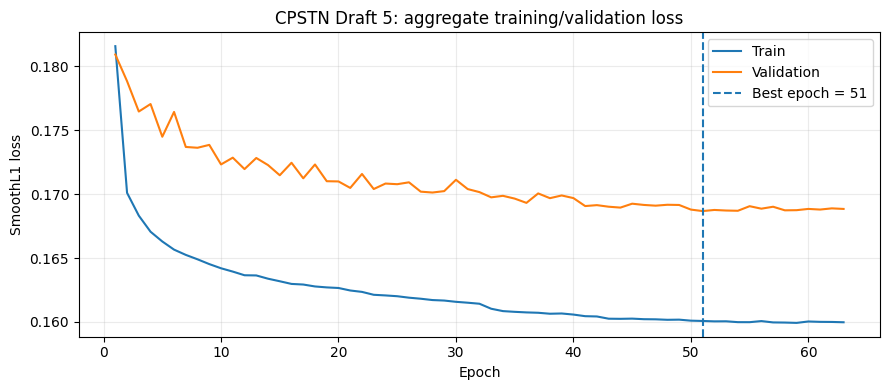

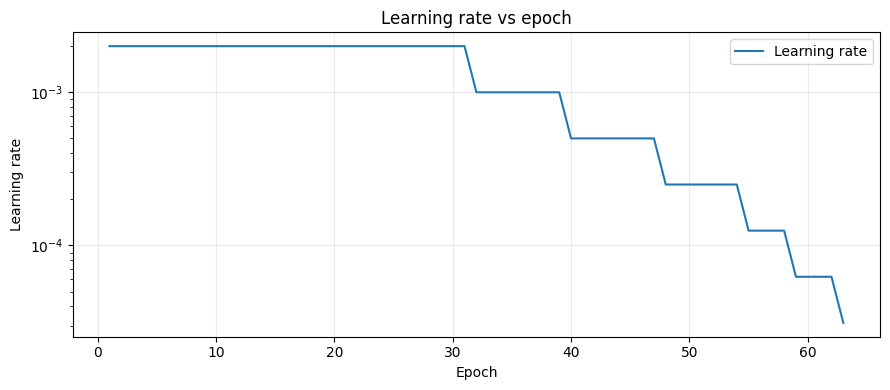

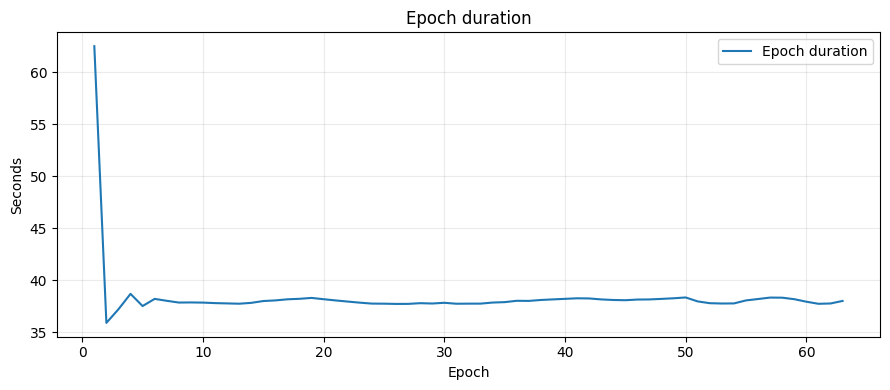

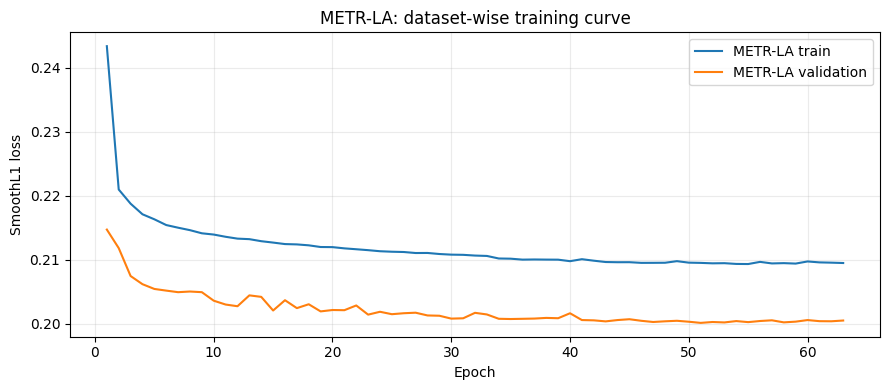

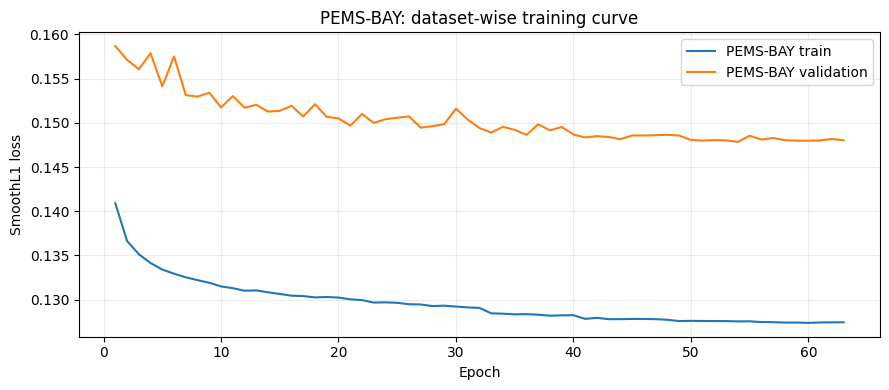

Average epoch time: 38.35 seconds
Total training time: 2416.15 seconds


In [12]:
# 11. Training curves
epochs = np.arange(1, len(history["train"]) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochs, history["train"], label="Train")
plt.plot(epochs, history["val"], label="Validation")
if best_epoch:
    plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("SmoothL1 loss")
plt.title("CPSTN Draft 5: aggregate training/validation loss")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "aggregate_loss.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(epochs, history["lr"], label="Learning rate")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate vs epoch")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "learning_rate.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(epochs, history["epoch_seconds"], label="Epoch duration")
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.title("Epoch duration")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "epoch_duration.png", dpi=150, bbox_inches="tight")
plt.show()

for name in used_datasets:
    plt.figure(figsize=(9, 4))
    plt.plot(epochs, history["dataset_train"][name], label=f"{name} train")
    plt.plot(epochs, history["dataset_val"][name], label=f"{name} validation")
    plt.xlabel("Epoch")
    plt.ylabel("SmoothL1 loss")
    plt.title(f"{name}: dataset-wise training curve")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{name}_loss.png", dpi=150, bbox_inches="tight")
    plt.show()

history_rows = []
for idx in range(len(history["train"])):
    row = {"epoch": idx + 1, "train_loss": history["train"][idx], "val_loss": history["val"][idx], "learning_rate": history["lr"][idx], "epoch_seconds": history["epoch_seconds"][idx]}
    for name in used_datasets:
        row[f"{name}_train_loss"] = history["dataset_train"][name][idx]
        row[f"{name}_val_loss"] = history["dataset_val"][name][idx]
    history_rows.append(row)
pd.DataFrame(history_rows).to_csv(RESULTS_DIR / "training_history.csv", index=False)

print("Average epoch time:", round(float(np.mean(history["epoch_seconds"])), 2), "seconds")
print("Total training time:", round(total_training_seconds, 2), "seconds")

## 9. Best-checkpoint verification

The notebook does not report training success merely because `torch.save()` returned. It reloads the checkpoint and verifies the model state, configuration, graph metadata, and dataset metadata.

In [13]:
# 12. Reload and verify the best checkpoint
if status in {"COMPLETED", "EARLY_STOPPED"} and CHECKPOINT_PATH.exists():
    try:
        ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    except TypeError:
        ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

    required_keys = {
        "model_state_dict", "optimizer_state_dict", "scheduler_state_dict",
        "epoch", "best_val_loss", "model_config", "training_config", "datasets",
        "dataset", "num_nodes", "input_steps", "horizon", "sensor_ids"
    }
    missing_keys = required_keys - set(ckpt.keys())
    if missing_keys:
        raise RuntimeError(f"CHECKPOINT FAILURE: missing keys {sorted(missing_keys)}")

    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    assert int(ckpt["epoch"]) == best_epoch
    assert np.isfinite(float(ckpt["best_val_loss"]))
    assert ckpt["training_config"]["datasets"] == used_datasets

    for name in used_datasets:
        meta = ckpt["datasets"][name]
        assert meta["num_nodes"] == prepared[name]["N"]
        assert len(meta["sensor_ids"]) == prepared[name]["N"]
        assert tuple(meta["graph_dimensions"]) == prepared[name]["graph_dimensions"]
        assert np.isfinite(np.asarray(meta["mean"])).all()
        assert np.isfinite(np.asarray(meta["std"])).all()
        assert np.isfinite(np.asarray(meta["adjacency_normalized"])).all()

    # A real forward pass after reload for every dataset.
    for name in used_datasets:
        loader = cached_loaders[name]["train"]
        xb, yb = next(iter(loader))
        with torch.no_grad():
            out = model(xb[:2].to(DEVICE, non_blocking=PIN_MEMORY), graphs[name])
        assert torch.isfinite(out).all()
        assert out.shape[-1] == prepared[name]["N"]
        del loader, xb, yb, out
        gc.collect()

    if not FINAL_CHECKPOINT_PATH.exists():
        raise RuntimeError(f"FINAL CHECKPOINT FAILURE: missing {FINAL_CHECKPOINT_PATH}")
    try:
        final_ckpt = torch.load(FINAL_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    except TypeError:
        final_ckpt = torch.load(FINAL_CHECKPOINT_PATH, map_location=DEVICE)
    if "model_state_dict" not in final_ckpt:
        raise RuntimeError("FINAL CHECKPOINT FAILURE: model_state_dict is missing.")
    model.load_state_dict(final_ckpt["model_state_dict"])
    model.eval()
    checkpoint_verified = True
    print("Best checkpoint file:", CHECKPOINT_PATH)
    print("Final checkpoint file:", FINAL_CHECKPOINT_PATH)
    print("Best/final checkpoint reload: PASS")
    print("State/config/graph metadata: PASS")
else:
    checkpoint_verified = False
    print("Checkpoint verification skipped because training did not produce a valid best checkpoint.")

Best checkpoint file: /content/cpstn_draft5/CPSTN(Training)-Draft5_best.pt
Final checkpoint file: /content/cpstn_draft5/CPSTN(Training)-Draft5_final.pt
Best/final checkpoint reload: PASS
State/config/graph metadata: PASS


## 10. Test-set sanity evaluation

This is not used to select the checkpoint. It is retained as an audit of the actual trained model and uses each dataset's own train-only scaler.

In [14]:
# 13. Real test evaluation for every successfully trained dataset
test_metrics = {}

if checkpoint_verified:
    for name in used_datasets:
        d = prepared[name]
        test_loader = cached_loaders[name]["test"]
        rep = dataset_reports[name]
        A_dense = graphs[name]

        preds_z, trues_z = [], []
        test_start = time.perf_counter()

        model.eval()
        with torch.no_grad():
            for X, Y in test_loader:
                X = X.to(DEVICE, non_blocking=PIN_MEMORY)
                pred = model(X, A_dense).float().cpu().numpy()
                preds_z.append(pred)
                trues_z.append(Y.numpy())

        pred_z = np.concatenate(preds_z, axis=0)
        true_z = np.concatenate(trues_z, axis=0)

        pred = pred_z * d["train_std"][None, None, :] + d["train_mean"][None, None, :]
        true = true_z * d["train_std"][None, None, :] + d["train_mean"][None, None, :]

        if not np.isfinite(pred).all() or not np.isfinite(true).all():
            raise FloatingPointError(f"{name}: NaN/Inf in test predictions or targets.")

        mae = float(np.mean(np.abs(pred - true)))
        rmse = float(np.sqrt(np.mean((pred - true) ** 2)))
        mape = float(
            np.mean(
                np.abs((pred - true) / np.maximum(np.abs(true), 5.0))
            ) * 100
        )

        np.savez_compressed(
            PREDICTIONS_DIR / f"{name}_predictions.npz",
            predictions=pred,
            targets=true,
        )

        test_metrics[name] = {
            "MAE": mae,
            "RMSE": rmse,
            "MAPE_percent": mape,
            "prediction_shape": list(pred.shape),
            "test_seconds": time.perf_counter() - test_start,
        }

        print(
            f"{name} TEST | MAE={mae:.4f} | RMSE={rmse:.4f} | "
            f"MAPE={mape:.2f}% | shape={pred.shape}"
        )

        del test_loader, preds_z, trues_z, pred_z, true_z, pred, true
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
else:
    print("Test evaluation skipped because checkpoint verification failed.")

METR-LA TEST | MAE=3.4454 | RMSE=6.8797 | MAPE=9.57% | shape=(6844, 12, 207)
PEMS-BAY TEST | MAE=1.9128 | RMSE=4.2782 | MAPE=4.40% | shape=(10413, 12, 325)


## 11. Final performance summary and diagnostics

All statements below are generated from measured values only. No accuracy improvement is claimed unless there is an actual comparison result.

In [15]:
# 14. Final numerical report
avg_epoch_time = float(np.mean(history["epoch_seconds"])) if history["epoch_seconds"] else float("nan")
samples_per_sec = None
if history["epoch_seconds"] and used_datasets:
    total_train_samples_per_epoch = sum(dataset_reports[n]["train_samples"] for n in used_datasets)
    samples_per_sec = total_train_samples_per_epoch / avg_epoch_time

final_report = {
    "training_status": status if checkpoint_verified else "FAILED",
    "used_datasets": used_datasets,
    "skipped_datasets": skipped_datasets,
    "dataset_file_status": dataset_file_status,
    "seed": SEED,
    "device": str(DEVICE),
    "cuda_available": CUDA_AVAILABLE,
    "pytorch_version": torch.__version__,
    "max_epochs": MAX_EPOCHS,
    "actual_epochs": len(history["train"]),
    "best_epoch": best_epoch,
    "best_validation_loss": float(best_val) if np.isfinite(best_val) else None,
    "early_stopping_occurred": len(history["train"]) < MAX_EPOCHS and status == "EARLY_STOPPED",
    "average_epoch_seconds": avg_epoch_time,
    "total_training_seconds": total_training_seconds,
    "samples_per_second": samples_per_sec,
    "model_parameter_count": params,
    "checkpoint_path": str(CHECKPOINT_PATH),
    "final_checkpoint_path": str(FINAL_CHECKPOINT_PATH),
    "checkpoint_verified": checkpoint_verified,
    "datasets": {
        name: {
            "sensors": prepared[name]["N"],
            "training_samples": dataset_reports[name]["train_samples"],
            "validation_samples": dataset_reports[name]["val_samples"],
            "test_samples": dataset_reports[name]["test_samples"],
            "graph_dimensions": list(prepared[name]["graph_dimensions"]),
            "normalization": prepared[name]["normalization"],
            "test_metrics": test_metrics.get(name),
        }
        for name in used_datasets
    },
}

print("=" * 78)
print("CPSTN DRAFT 5 FINAL REPORT")
print("=" * 78)
print("TRAINING STATUS :", final_report["training_status"])
print("USED DATASETS   :", ", ".join(used_datasets))
print("SKIPPED DATASETS:", skipped_datasets if skipped_datasets else "None")
print("DEVICE          :", DEVICE)
print("CUDA AVAILABLE  :", CUDA_AVAILABLE)
print("MAX EPOCHS      :", MAX_EPOCHS)
print("ACTUAL EPOCHS   :", len(history["train"]))
print("BEST EPOCH      :", best_epoch)
print("BEST VAL LOSS   :", final_report["best_validation_loss"])
print("EARLY STOPPED   :", final_report["early_stopping_occurred"])
print("AVG EPOCH TIME  :", round(avg_epoch_time, 2), "s")
print("TOTAL TIME      :", round(total_training_seconds, 2), "s")
print("SAMPLES/SECOND  :", None if samples_per_sec is None else round(samples_per_sec, 2))
print("PARAMETERS      :", f"{params:,}")
print("CHECKPOINT      :", CHECKPOINT_PATH)
print("CHECKPOINT TEST :", checkpoint_verified)

print("\nDATASET DETAILS")
for name in used_datasets:
    d = final_report["datasets"][name]
    print(
        f"{name}: sensors={d['sensors']} | train={d['training_samples']} | "
        f"val={d['validation_samples']} | test={d['test_samples']} | "
        f"graph={tuple(d['graph_dimensions'])}"
    )
    if d["test_metrics"]:
        print(
            f"  Test MAE={d['test_metrics']['MAE']:.4f}, "
            f"RMSE={d['test_metrics']['RMSE']:.4f}, "
            f"MAPE={d['test_metrics']['MAPE_percent']:.2f}%"
        )

CPSTN DRAFT 5 FINAL REPORT
TRAINING STATUS : EARLY_STOPPED
USED DATASETS   : METR-LA, PEMS-BAY
SKIPPED DATASETS: None
DEVICE          : cuda
CUDA AVAILABLE  : True
MAX EPOCHS      : 200
ACTUAL EPOCHS   : 63
BEST EPOCH      : 51
BEST VAL LOSS   : 0.16866769432025366
EARLY STOPPED   : True
AVG EPOCH TIME  : 38.35 s
TOTAL TIME      : 2416.15 s
SAMPLES/SECOND  : 1575.81
PARAMETERS      : 26,668
CHECKPOINT      : /content/cpstn_draft5/CPSTN(Training)-Draft5_best.pt
CHECKPOINT TEST : True

DATASET DETAILS
METR-LA: sensors=207 | train=23967 | val=3416 | test=6844 | graph=(207, 207)
  Test MAE=3.4454, RMSE=6.8797, MAPE=9.57%
PEMS-BAY: sensors=325 | train=36458 | val=5200 | test=10413 | graph=(325, 325)
  Test MAE=1.9128, RMSE=4.2782, MAPE=4.40%


In [16]:
# 15. Textual interpretation based only on calculated values
print("\nDIAGNOSTIC SUMMARY")
if final_report["training_status"] == "FAILED":
    print("- Training did not satisfy the success criteria.")
else:
    print(f"- Training used: {', '.join(used_datasets)}.")
    print(f"- Best aggregate validation loss occurred at epoch {best_epoch}.")
    print(
        "- Early stopping occurred."
        if final_report["early_stopping_occurred"]
        else "- Training reached the configured maximum epoch count."
    )
    print(
        f"- Validation loss changed from {history['val'][0]:.6f} "
        f"to {history['val'][-1]:.6f} across the recorded epochs."
    )
    print(f"- Average epoch duration: {avg_epoch_time:.2f} seconds.")
    if samples_per_sec is not None:
        print(f"- Approximate training throughput: {samples_per_sec:.2f} samples/second.")
    print("- Dataset-specific graphs and normalization statistics were kept separate.")
    print("- No A* component is included in this training pipeline.")
    print(
        "- Checkpoint verification succeeded."
        if checkpoint_verified
        else "- Checkpoint verification FAILED."
    )

if skipped_datasets:
    print("\nWARNINGS")
    for name, reason in skipped_datasets.items():
        print(f"- {name}: {reason}")


DIAGNOSTIC SUMMARY
- Training used: METR-LA, PEMS-BAY.
- Best aggregate validation loss occurred at epoch 51.
- Early stopping occurred.
- Validation loss changed from 0.180899 to 0.168834 across the recorded epochs.
- Average epoch duration: 38.35 seconds.
- Approximate training throughput: 1575.81 samples/second.
- Dataset-specific graphs and normalization statistics were kept separate.
- No A* component is included in this training pipeline.
- Checkpoint verification succeeded.


In [17]:
# 16. Persist the final report
with open(SUMMARY_PATH, "w") as f:
    json.dump(final_report, f, indent=2, default=str)

print("Summary saved:", SUMMARY_PATH)

Summary saved: /content/cpstn_draft5/CPSTN(Training)-Draft5_summary.json


## 12. Final integrity checks

The notebook reports `SUCCESS` only when:
- valid training occurred,
- validation occurred,
- a best checkpoint exists,
- checkpoint reload succeeds,
- model forward sanity checks pass after reload,
- metadata and predictions pass finite-value checks.

In [18]:
# 17. Final integrity / success gate
assert used_datasets, "No datasets were successfully used."
assert len(history["train"]) == len(history["val"]) == len(history["lr"]) == len(history["epoch_seconds"])
assert len(history["train"]) > 0

if checkpoint_verified:
    assert CHECKPOINT_PATH.exists()
    assert FINAL_CHECKPOINT_PATH.exists()
    assert best_epoch >= 1
    assert np.isfinite(best_val)
    assert len(used_datasets) >= 1
    for name in used_datasets:
        assert prepared[name]["A"].shape == (prepared[name]["N"], prepared[name]["N"])
        assert prepared[name]["A_norm"].shape == (prepared[name]["N"], prepared[name]["N"])
        assert np.isfinite(prepared[name]["A_norm"]).all()

    final_report["training_status"] = (
        "EARLY_STOPPED" if final_report["early_stopping_occurred"] else "COMPLETED"
    )
else:
    final_report["training_status"] = "FAILED"

with open(SUMMARY_PATH, "w") as f:
    json.dump(final_report, f, indent=2, default=str)

print("=" * 78)
print("CPSTN DRAFT 5 INTEGRITY CHECK:", "PASS" if checkpoint_verified else "FAILED")
print("=" * 78)
print("TRAINING STATUS:", final_report["training_status"])
print("USED DATASETS:", used_datasets)
print("BEST EPOCH:", best_epoch)
print("BEST VALIDATION LOSS:", final_report["best_validation_loss"])
print("CHECKPOINT:", CHECKPOINT_PATH)
print("SUMMARY:", SUMMARY_PATH)

if final_report["training_status"] == "FAILED":
    raise RuntimeError("Training did not satisfy the final success criteria.")

CPSTN DRAFT 5 INTEGRITY CHECK: PASS
TRAINING STATUS: EARLY_STOPPED
USED DATASETS: ['METR-LA', 'PEMS-BAY']
BEST EPOCH: 51
BEST VALIDATION LOSS: 0.16866769432025366
CHECKPOINT: /content/cpstn_draft5/CPSTN(Training)-Draft5_best.pt
SUMMARY: /content/cpstn_draft5/CPSTN(Training)-Draft5_summary.json


In [ ]:
# 18. FINAL PROJECT PACKAGE

from pathlib import Path
import json
import shutil
import zipfile
import torch

# Paths
PACKAGE_ROOT = Path("/content/CPSTN_FINAL")
ZIP_PATH = Path("/content/CPSTN_FINAL.zip")
NOTEBOOK_NAME = "CPSTN(Training)-Draft5.ipynb"
FINAL_NOTEBOOK_PATH = PACKAGE_ROOT / "notebook" / NOTEBOOK_NAME

# Clean old package
if PACKAGE_ROOT.exists():
    shutil.rmtree(PACKAGE_ROOT)

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

# Create package structure
for folder in [
    "notebook",
    "checkpoints",
    "data",
    "config",
    "results/predictions",
    "results/plots",
    "src",
]:
    (PACKAGE_ROOT / folder).mkdir(parents=True, exist_ok=True)

# Validate required runtime paths
required_paths = {
    "best checkpoint": Path(CHECKPOINT_PATH),
    "final checkpoint": Path(FINAL_CHECKPOINT_PATH),
    "summary": Path(SUMMARY_PATH),
}

for name, path in required_paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Required artifact missing: {name}: {path}")

# Validate checkpoint files
def validate_checkpoint(path, name):
    try:
        try:
            checkpoint = torch.load(
                path,
                map_location="cpu",
                weights_only=False,
            )
        except TypeError:
            checkpoint = torch.load(
                path,
                map_location="cpu",
            )
    except Exception as e:
        raise RuntimeError(
            f"{name} checkpoint could not be loaded: {e}"
        )

    if not isinstance(checkpoint, dict):
        raise RuntimeError(
            f"{name} checkpoint is not a valid checkpoint dictionary."
        )

    if "model_state_dict" not in checkpoint:
        raise RuntimeError(
            f"{name} checkpoint missing 'model_state_dict'."
        )

    print(f"{name} checkpoint load: PASS")
    return checkpoint

best_checkpoint = validate_checkpoint(
    Path(CHECKPOINT_PATH),
    "Best",
)

final_checkpoint = validate_checkpoint(
    Path(FINAL_CHECKPOINT_PATH),
    "Final",
)

# Locate current notebook
notebook_candidates = [
    Path("/content") / NOTEBOOK_NAME,
    Path("/content/drive/MyDrive") / NOTEBOOK_NAME,
]

source_notebook = next(
    (p for p in notebook_candidates if p.exists()),
    None,
)

# Export notebook from Colab
if source_notebook is not None:
    shutil.copy2(
        source_notebook,
        FINAL_NOTEBOOK_PATH,
    )
else:
    try:
        from google.colab import _message

        payload = _message.blocking_request(
            "get_ipynb",
            request="",
            timeout_sec=30,
        )

        notebook_json = None

        if isinstance(payload, dict):
            notebook_json = payload.get("ipynb")

            if notebook_json is None:
                notebook_json = payload.get("notebook")

            if notebook_json is None:
                data = payload.get("data")
                if isinstance(data, dict):
                    notebook_json = data.get("ipynb")

        if notebook_json is None:
            raise RuntimeError(
                "Colab returned no notebook JSON."
            )

        if isinstance(notebook_json, str):
            notebook_data = json.loads(notebook_json)
        elif isinstance(notebook_json, dict):
            notebook_data = notebook_json
        else:
            raise RuntimeError(
                "Invalid notebook JSON returned by Colab."
            )

        if not isinstance(notebook_data, dict):
            raise RuntimeError(
                "Notebook export is not a valid JSON object."
            )

        if "cells" not in notebook_data:
            raise RuntimeError(
                "Exported notebook does not contain cells."
            )

        with open(
            FINAL_NOTEBOOK_PATH,
            "w",
            encoding="utf-8",
        ) as f:
            json.dump(
                notebook_data,
                f,
                indent=2,
                ensure_ascii=False,
            )

    except Exception as e:
        raise RuntimeError(
            "Required artifact missing: the current notebook "
            f"could not be exported from Colab.\nReason: {e}"
        )

# Validate exported notebook
with open(
    FINAL_NOTEBOOK_PATH,
    "r",
    encoding="utf-8",
) as f:
    notebook_data = json.load(f)

if "cells" not in notebook_data:
    raise RuntimeError(
        "Exported notebook validation failed: cells missing."
    )

print("Notebook export: PASS")

# Copy checkpoints
shutil.copy2(
    CHECKPOINT_PATH,
    PACKAGE_ROOT / "checkpoints" / Path(CHECKPOINT_PATH).name,
)

shutil.copy2(
    FINAL_CHECKPOINT_PATH,
    PACKAGE_ROOT / "checkpoints" / Path(FINAL_CHECKPOINT_PATH).name,
)

# Copy summary
shutil.copy2(
    SUMMARY_PATH,
    PACKAGE_ROOT / "results" / Path(SUMMARY_PATH).name,
)

# Copy optional artifacts
optional_files = [
    globals().get("HISTORY_PATH"),
    globals().get("TEST_METRICS_PATH"),
    globals().get("PREDICTIONS_PATH"),
    globals().get("PLOT_PATH"),
    globals().get("DATASET_METADATA_PATH"),
    globals().get("ADJACENCY_PATH"),
    globals().get("CONFIG_PATH"),
]

for item in optional_files:
    if item is None:
        continue

    path = Path(item)

    if not path.exists():
        continue

    suffix = path.suffix.lower()

    if suffix in [".png", ".jpg", ".jpeg", ".pdf"]:
        destination = PACKAGE_ROOT / "results" / "plots" / path.name

    elif "prediction" in path.name.lower():
        destination = (
            PACKAGE_ROOT
            / "results"
            / "predictions"
            / path.name
        )

    elif "adj" in path.name.lower():
        destination = PACKAGE_ROOT / "data" / path.name

    elif "config" in path.name.lower():
        destination = PACKAGE_ROOT / "config" / path.name

    else:
        destination = PACKAGE_ROOT / "data" / path.name

    shutil.copy2(path, destination)

# Create config.json if missing
config_file = PACKAGE_ROOT / "config" / "config.json"

if not config_file.exists():
    config_data = {
        "project": "CPSTN",
        "framework": "PyTorch",
        "device": str(
            globals().get(
                "DEVICE",
                "cuda" if torch.cuda.is_available() else "cpu",
            )
        ),
    }

    with open(
        config_file,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            config_data,
            f,
            indent=2,
        )

# Create requirements.txt
requirements_file = PACKAGE_ROOT / "requirements.txt"

requirements_file.write_text(
    "\n".join([
        "torch",
        "numpy",
        "pandas",
        "scikit-learn",
        "matplotlib",
        "seaborn",
        "jupyter",
        "nbformat",
    ]) + "\n",
    encoding="utf-8",
)

# Create README
readme_file = PACKAGE_ROOT / "README.md"

readme_file.write_text(
    """# CPSTN

Traffic forecasting project using the CPSTN methodology.

## Main contents

- notebook/      Training notebook
- checkpoints/   Best and final model checkpoints
- data/          Dataset metadata and supporting arrays
- config/        Configuration files
- results/       Predictions, plots, and summaries
- src/           Source documentation
- requirements.txt

## Execution

Run the notebook in Google Colab with GPU acceleration enabled.

The intended environment is an NVIDIA Tesla T4 or equivalent CUDA GPU.
""",
    encoding="utf-8",
)

# Create source documentation
src_readme = PACKAGE_ROOT / "src" / "README.txt"

src_readme.write_text(
    """CPSTN source and implementation documentation.

The primary implementation is contained in the training notebook.
""",
    encoding="utf-8",
)

# Verify required package files
required_package_files = [
    FINAL_NOTEBOOK_PATH,
    PACKAGE_ROOT / "checkpoints" / Path(CHECKPOINT_PATH).name,
    PACKAGE_ROOT / "checkpoints" / Path(FINAL_CHECKPOINT_PATH).name,
    PACKAGE_ROOT / "results" / Path(SUMMARY_PATH).name,
    PACKAGE_ROOT / "config" / "config.json",
    PACKAGE_ROOT / "requirements.txt",
    PACKAGE_ROOT / "README.md",
    PACKAGE_ROOT / "src" / "README.txt",
]

for path in required_package_files:
    if not path.exists():
        raise FileNotFoundError(
            f"Required package file missing: {path}"
        )

# Create ZIP
with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as zf:

    for file_path in PACKAGE_ROOT.rglob("*"):
        if file_path.is_file():
            zf.write(
                file_path,
                file_path.relative_to(PACKAGE_ROOT.parent),
            )

# Validate ZIP
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    bad_file = zf.testzip()

    if bad_file is not None:
        raise RuntimeError(
            f"ZIP integrity check failed: {bad_file}"
        )

    zip_names = set(zf.namelist())

required_zip_files = {
    f"CPSTN_FINAL/notebook/{NOTEBOOK_NAME}",
    f"CPSTN_FINAL/checkpoints/{Path(CHECKPOINT_PATH).name}",
    f"CPSTN_FINAL/checkpoints/{Path(FINAL_CHECKPOINT_PATH).name}",
    f"CPSTN_FINAL/results/{Path(SUMMARY_PATH).name}",
    "CPSTN_FINAL/config/config.json",
    "CPSTN_FINAL/requirements.txt",
    "CPSTN_FINAL/README.md",
    "CPSTN_FINAL/src/README.txt",
}

missing_zip_files = required_zip_files - zip_names

if missing_zip_files:
    raise RuntimeError(
        "ZIP validation failed. Missing:\n"
        + "\n".join(sorted(missing_zip_files))
    )

# Final package report
zip_size_mb = ZIP_PATH.stat().st_size / (1024 * 1024)

print()
print("=" * 60)
print("FINAL PROJECT PACKAGE")
print("=" * 60)
print(f"ZIP: {ZIP_PATH}")
print(f"SIZE: {zip_size_mb:.2f} MB")
print("STATUS: READY")
print()
print("CONTENTS:")

for file_path in sorted(PACKAGE_ROOT.rglob("*")):
    if file_path.is_file():
        print(
            f"  {file_path.relative_to(PACKAGE_ROOT)}"
        )

print()
print("ZIP integrity: PASS")
print("Required files: PASS")
print("Checkpoint validation: PASS")
print("Notebook validation: PASS")
print("=" * 60)

# Download package
from google.colab import files

files.download(str(ZIP_PATH))